# Single-Image Interventions (Experiments)

In [ ]:
# Test time interventions:

In [ ]:
ds["train"]
ds["validation"]
ds["test"]

Dataset({
    features: ['image', 'label', 'bbox', 'label_name', 'attributes'],
    num_rows: 5794
})

In [ ]:
import pandas as pd
# id2label function
id2label = ds["train"].features["label"].int2str
# number of classes (200 in CUB-200)
num_classes = ds["train"].features["label"].num_classes

rows = []
for cls_id in range(num_classes):
    rows.append({
        "class_id": cls_id,
        "class_name": id2label(cls_id)
    })
df_classes = pd.DataFrame(rows)
df_classes

,class_id,class_name
0,0,Black_footed_Albatross
1,1,Laysan_Albatross
2,2,Sooty_Albatross
3,3,Groove_billed_Ani
4,4,Crested_Auklet
...,...,...
195,195,House_Wren
196,196,Marsh_Wren
197,197,Rock_Wren
198,198,Winter_Wren


In [ ]:
for i in range(num_classes):
    print(f"{i:3d}  ->  {id2label(i)}")

  0  ->  Black_footed_Albatross
  1  ->  Laysan_Albatross
  2  ->  Sooty_Albatross
  3  ->  Groove_billed_Ani
  4  ->  Crested_Auklet
  5  ->  Least_Auklet
  6  ->  Parakeet_Auklet
  7  ->  Rhinoceros_Auklet
  8  ->  Brewer_Blackbird
  9  ->  Red_winged_Blackbird
 10  ->  Rusty_Blackbird
 11  ->  Yellow_headed_Blackbird
 12  ->  Bobolink
 13  ->  Indigo_Bunting
 14  ->  Lazuli_Bunting
 15  ->  Painted_Bunting
 16  ->  Cardinal
 17  ->  Spotted_Catbird
 18  ->  Gray_Catbird
 19  ->  Yellow_breasted_Chat
 20  ->  Eastern_Towhee
 21  ->  Chuck_will_Widow
 22  ->  Brandt_Cormorant
 23  ->  Red_faced_Cormorant
 24  ->  Pelagic_Cormorant
 25  ->  Bronzed_Cowbird
 26  ->  Shiny_Cowbird
 27  ->  Brown_Creeper
 28  ->  American_Crow
 29  ->  Fish_Crow
 30  ->  Black_billed_Cuckoo
 31  ->  Mangrove_Cuckoo
 32  ->  Yellow_billed_Cuckoo
 33  ->  Gray_crowned_Rosy_Finch
 34  ->  Purple_Finch
 35  ->  Northern_Flicker
 36  ->  Acadian_Flycatcher
 37  ->  Great_Crested_Flycatcher
 38  ->  Least_Flyca

In [ ]:
# Class Distribution in our Dataset:
from collections import Counter

# count labels in train, val, test
train_counts = Counter(ds["train"]["label"])
val_counts   = Counter(ds["validation"]["label"])
test_counts  = Counter(ds["test"]["label"])

# convert to DataFrame
df_dist = pd.DataFrame({
    "class_id": list(train_counts.keys()),
    "train_count": list(train_counts.values()),
    "val_count": [val_counts[i] for i in train_counts.keys()],
    "test_count": [test_counts[i] for i in train_counts.keys()],
})

# add class names
df_dist["class_name"] = df_dist["class_id"].apply(id2label)

# total images per class
df_dist["total"] = df_dist["train_count"] + df_dist["val_count"] + df_dist["test_count"]

df_dist = df_dist.sort_values("total", ascending=False)

display(df_dist.head(10))   # top 10 most common
display(df_dist.tail(10))   # rarest classes

,class_id,train_count,val_count,test_count,class_name,total
0,160,27,3,30,Blue_winged_Warbler,60
1,95,27,3,30,Hooded_Oriole,60
2,43,27,3,30,Frigatebird,60
4,1,27,3,30,Laysan_Albatross,60
7,143,27,3,30,Common_Tern,60
5,198,27,3,30,Winter_Wren,60
11,82,27,3,30,White_breasted_Kingfisher,60
9,37,27,3,30,Great_Crested_Flycatcher,60
71,68,27,3,30,Rufous_Hummingbird,60
68,90,27,3,30,Mockingbird,60


,class_id,train_count,val_count,test_count,class_name,total
50,150,27,3,21,Black_capped_Vireo,51
17,112,27,3,20,Baird_Sparrow,50
35,100,27,3,20,White_Pelican,50
116,186,27,3,20,American_Three_toed_Woodpecker,50
150,64,27,3,20,Slaty_backed_Gull,50
10,104,27,3,19,Whip_poor_Will,49
64,7,27,3,18,Rhinoceros_Auklet,48
66,17,27,3,15,Spotted_Catbird,45
33,4,27,3,14,Crested_Auklet,44
104,5,27,3,11,Least_Auklet,41


Reminder...

CUB attribute names:
* CUB has 312 attributes like:

wing_color::black/
bill_shape::curved/
belly_color::yellow

* CUB_ATTRIBUTE_NAMES should already be a list[str] of length 312 with real names not just their number or ids.

In [ ]:
# Checking again what CUB_ATTRIBUTE_NAMES contains:
print(len(CUB_ATTRIBUTE_NAMES))
print(CUB_ATTRIBUTE_NAMES[:20])

312
['attr_001', 'attr_002', 'attr_003', 'attr_004', 'attr_005', 'attr_006', 'attr_007', 'attr_008', 'attr_009', 'attr_010', 'attr_011', 'attr_012', 'attr_013', 'attr_014', 'attr_015', 'attr_016', 'attr_017', 'attr_018', 'attr_019', 'attr_020']


In [ ]:
# Checking what CUB_ATTRIBUTE_NAMES contains:
# Making CUB_ATTRIBUTE_NAMES[i] be the semantic attribute,
# During single-image intervention, getting real names instead of id like "attr_011":
import os
attr_path = os.path.join(ATTR_DIR, "/content/data/attributes.txt")
names = []

with open(attr_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # each line is like: "1 bill_shape::curved"
        parts = line.split()
        attr_id = int(parts[0])      # 1 ... 312
        attr_name = parts[1]         # "bill_shape::curved"
        names.append(attr_name)

CUB_ATTRIBUTE_NAMES = names
print(len(CUB_ATTRIBUTE_NAMES))
print(CUB_ATTRIBUTE_NAMES[:20])

312
['has_bill_shape::curved_(up_or_down)', 'has_bill_shape::dagger', 'has_bill_shape::hooked', 'has_bill_shape::needle', 'has_bill_shape::hooked_seabird', 'has_bill_shape::spatulate', 'has_bill_shape::all-purpose', 'has_bill_shape::cone', 'has_bill_shape::specialized', 'has_wing_color::blue', 'has_wing_color::brown', 'has_wing_color::iridescent', 'has_wing_color::purple', 'has_wing_color::rufous', 'has_wing_color::grey', 'has_wing_color::yellow', 'has_wing_color::olive', 'has_wing_color::green', 'has_wing_color::pink', 'has_wing_color::orange']


In [ ]:
# Attribute / Concept Distribution:
# how balanced or imbalanced the 312 concepts are:
# Each attribute is binary, so I computed how many times each concept is “present”:
attrs = np.stack(ds["train"]["attributes"])  # shape [N,312]
df_attr = pd.DataFrame({
    "concept_idx": range(312),
    "concept_name": CUB_ATTRIBUTE_NAMES,
    "positive_count": attrs.sum(axis=0),
    "negative_count": attrs.shape[0] - attrs.sum(axis=0),
})

df_attr = df_attr.sort_values("positive_count", ascending=False)
display(df_attr.head(10))   # most common attributes
display(df_attr.tail(10))   # rarest attributes

,concept_idx,concept_name,positive_count,negative_count
145,145,has_eye_color::black,4493,901
244,244,has_belly_pattern::solid,3100,2294
151,151,has_bill_length::shorter_than_head,3037,2357
54,54,has_breast_pattern::solid,2983,2411
218,218,has_size::small_(5_-_9_in),2784,2610
235,235,has_shape::perching-like,2628,2766
289,289,has_bill_color::black,2386,3008
20,20,has_wing_color::black,2348,3046
35,35,has_upperparts_color::black,2105,3289
51,51,has_underparts_color::white,2097,3297


,concept_idx,concept_name,positive_count,negative_count
170,170,has_under_tail_color::purple,18,5376
200,200,has_belly_color::purple,17,5377
270,270,has_leg_color::olive,16,5378
281,281,has_bill_color::purple,14,5380
286,286,has_bill_color::green,14,5380
108,108,has_breast_color::purple,13,5381
141,141,has_eye_color::olive,13,5381
142,142,has_eye_color::green,11,5383
271,271,has_leg_color::green,9,5385
137,137,has_eye_color::purple,8,5386


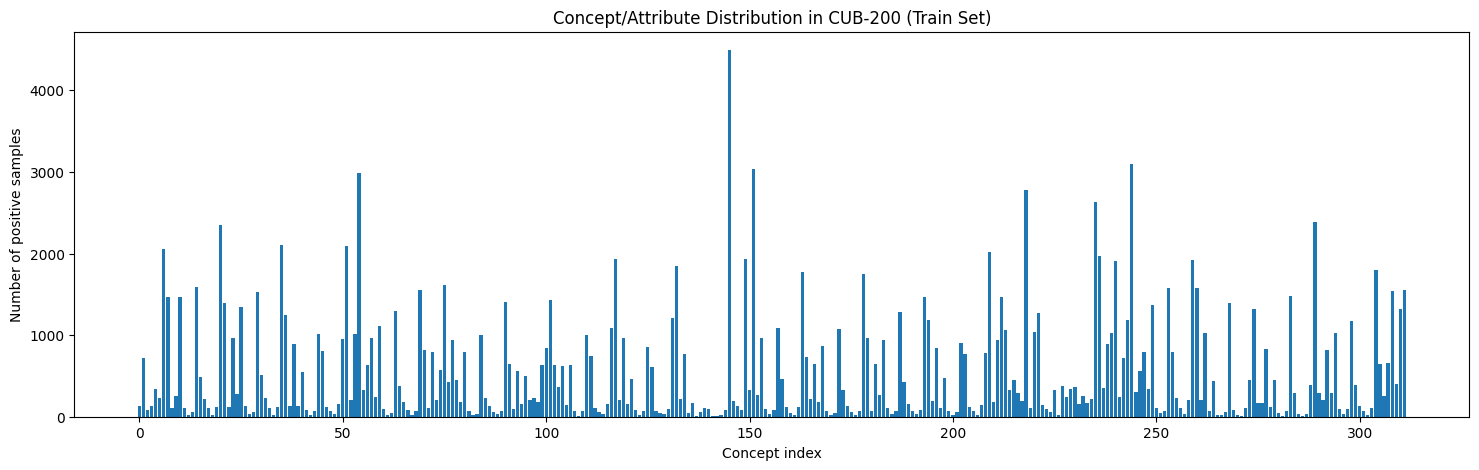

In [ ]:
# keep original order
df_plot = df_attr.sort_values("concept_idx")

plt.figure(figsize=(18,5))
plt.bar(df_plot["concept_idx"], df_plot["positive_count"])
plt.title("Concept/Attribute Distribution in CUB-200 (Train Set)")
plt.xlabel("Concept index")
plt.ylabel("Number of positive samples")
plt.show()

In [ ]:
# 1. Single-image intervention experiments:
import torch
@torch.no_grad()
def intervene_on_image(
    model,
    x,                 # single image tensor [C,H,W]
    concept_changes,   # dict {concept_idx: value_in_[0,1]}
    device=device
):
    """
    Runing our model on one image, then overwrite some concept probabilities
    and see how the predicted class changes.
    Returning:
      base_pred      : int (class before intervention)
      new_pred       : int (class after intervention)
      base_c_probs   : 1D tensor [n_concepts] before
      new_c_probs    : 1D tensor [n_concepts] after
    """
    model.eval()
    # put image on device and add batch dim
    x = x.to(device).unsqueeze(0)  # [1,C,H,W]

    # 1) forward to get concept probs
    feats = model.backbone(x)
    c_probs, c_logits = model.concepts(feats)     # [1, n_concepts]
    base_logits = model.label(c_probs)
    base_pred = base_logits.argmax(dim=1).item()

    # 2) clone and modify the concept vector
    c_mod = c_probs.clone()
    for idx, val in concept_changes.items():
        c_mod[0, idx] = float(val)

    # 3) recompute label from modified concepts
    new_logits = model.label(c_mod)
    new_pred = new_logits.argmax(dim=1).item()

    return base_pred, new_pred, c_probs[0].cpu(), c_mod[0].cpu()

--- A single intervention:

Loading one random test image (i = a random number... ).

Checking its true class : Black_footed_Albatross for example.

Selecting one random concept to modify:

Concept 200 = has_belly_color::purple

Runing the model normally : gets base prediction.

Editing the concept vector by force-setting:
concept 200 = 0.9. (can be between 0.0 - 1.0)

Runing the classifier again : geting new prediction.

Printing both predictions and the concept’s before/after values.

“If I tell the model that this bird has purple belly (prob=0.9), does the predicted species change?”

Interpretation of this small intervenytion:

The model originally believed the bird’s belly is not purple (when prob is small near 0.0).

I forced it to believe it’s somewhat purple: (0.9).

Prediction did NOT change. Why?

Because purple belly color is not an important concept for identifying for example Black_footed_Albatross in my trained CBM.

Its label-head weight for this concept is probably small, so changing it barely affects the classifier.

Changing the concept “belly color: purple” does NOT influence the species prediction, because that concept is not relevant for classifying a Black_footed_Albatross.

In a Concept Bottleneck Model:
The label head sees 312-dimensional concept vector.
Changing ONE concept slightly (e.g. 0.030 → 1.0) rarely changes the output.
Only high-weight concepts (strong classifier coefficients) significantly affect the label.
Concepts that do not discriminate this species from others will not change the class.
It usually means this concept is not critical for this decision.
This aligns with Koh et al.’s “faithfulness analysis” discussions — many concepts have weak influence on particular classes.

Asking meaningful questions:
Does changing wing color change the predicted species?
Does changing the bird’s bill shape affect prediction?
Which concepts are most influential for this image?

0.03 → 1.0 still does not change label
→ concept is irrelevant for this class.

Image index: 500
Class id   : 19
Class name : Yellow_breasted_Chat


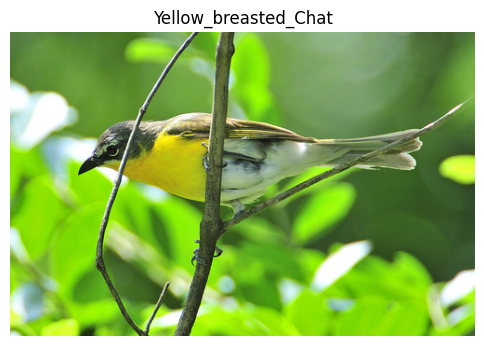

In [ ]:
import matplotlib.pyplot as pl
# pick index (a random image)
idx = 500
# loading sample (image, class label, attributes)
sample = ds["test"][idx]
img = sample["image"]        # PIL image
cls = sample["label"]        # int
attrs = sample["attributes"] # vector of length 312

# class name mapping
id2label = ds["train"].features["label"].int2str

print("Image index:", idx)
print("Class id   :", cls)
print("Class name :", id2label(cls))

# show image
plt.figure(figsize=(6,9))
plt.imshow(img)
plt.axis("off")
plt.title(id2label(cls))
plt.show()

In [ ]:
# Turn the PIL image into a tensor (same transform as training)
from torchvision import transforms
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])
x = test_transform(img).to(device)   # shape [3,224,224]

In [ ]:
#Runing my CBM on this image to get prediction + concepts:
model_for_intervention = model_s2 # or model_joint
model_for_intervention.eval()
with torch.no_grad():
    feats = model_for_intervention.backbone(x.unsqueeze(0))
    c_probs, c_logits = model_for_intervention.concepts(feats)
    class_logits = model_for_intervention.label(c_probs)
    pred_class = int(class_logits.argmax(1).item())

print("CBM predicted class:", pred_class, id2label(pred_class))

CBM predicted class: 97 Scott_Oriole


In [ ]:
# Adding the intervene_on_image helper:
@torch.no_grad()
def intervene_on_image(model, x, concept_changes, device=device):
    model.eval()
    if x.dim() == 3:
        x = x.unsqueeze(0).to(device)
    elif x.dim() == 4:
        x = x.to(device)
    else:
        raise ValueError(f"Unexpected x.dim() = {x.dim()}")

    feats = model.backbone(x)
    c_probs, c_logits = model.concepts(feats)
    base_logits = model.label(c_probs)
    base_pred = int(base_logits.argmax(1).item())

    c_mod = c_probs.clone()
    for idx, val in concept_changes.items():
        c_mod[0, idx] = float(val)

    new_logits = model.label(c_mod)
    new_pred = int(new_logits.argmax(1).item())

    return base_pred, new_pred, c_probs[0].cpu(), c_mod[0].cpu()

In [ ]:
# Doing a single-image intervention on image
# 500: has_wing_color::yellow 0.9
concept_idx = 15 # example
concept_name = CUB_ATTRIBUTE_NAMES[concept_idx]
print("Intervening on:", concept_idx, concept_name)

base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x,
    {concept_idx: 1.0},   # or 0.0 (0 ... 1)
    device=device
)

print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred, id2label(new_pred))
print(concept_name, "before:", float(c_before[concept_idx]), "after:", float(c_after[concept_idx]))

Intervening on: 15 has_wing_color::yellow
Base: 97 Scott_Oriole
New : 97 Scott_Oriole
has_wing_color::yellow before: 0.909272313117981 after: 1.0


In [ ]:
# 500: has_wing_color::yellow 0.9
concept_idx = 15  # example
concept_name = CUB_ATTRIBUTE_NAMES[concept_idx]
print("Intervening on:", concept_idx, concept_name)
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x,
    {concept_idx: 0.0},   # or 0.0
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred, id2label(new_pred))
print(concept_name, "before:", float(c_before[concept_idx]), "after:", float(c_after[concept_idx]))

Intervening on: 15 has_wing_color::yellow
Base: 97 Scott_Oriole
New : 97 Scott_Oriole
has_wing_color::yellow before: 0.909272313117981 after: 0.0


In [ ]:
concept_idx = 139  # example
concept_name = CUB_ATTRIBUTE_NAMES[concept_idx]
print("Intervening on:", concept_idx, concept_name)
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x,
    {concept_idx: 0.2},   # or 0.0
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred, id2label(new_pred))
print(concept_name, "before:", float(c_before[concept_idx]), "after:", float(c_after[concept_idx]))

Intervening on: 139 has_eye_color::grey
Base: 97 Scott_Oriole
New : 97 Scott_Oriole
has_eye_color::grey before: 0.02591046318411827 after: 0.20000000298023224


In [ ]:
concept_idx = 139  # example
concept_name = CUB_ATTRIBUTE_NAMES[concept_idx]
print("Intervening on:", concept_idx, concept_name)
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x,
    {concept_idx: 0.9},   # or 0.0
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred, id2label(new_pred))
print(concept_name, "before:", float(c_before[concept_idx]), "after:", float(c_after[concept_idx]))

Intervening on: 139 has_eye_color::grey
Base: 97 Scott_Oriole
New : 97 Scott_Oriole
has_eye_color::grey before: 0.02591046318411827 after: 0.8999999761581421


In [ ]:
# Build a table: concepts + weights + this image’s concept probs
import torch
# weights for this predicted class
row = W[pred_class]
if isinstance(row, torch.Tensor):
    row = row.detach().cpu().numpy()

df = pd.DataFrame({
    "concept_idx": range(len(CUB_ATTRIBUTE_NAMES)),
    "concept_name": CUB_ATTRIBUTE_NAMES,
    "pred_prob": c_probs[0].cpu().numpy(),   # this image's concept probs
    "weight": row,                           # class-level concept weights
})

In [ ]:
# Top positive concepts (strong evidence FOR this class):
df_top = df.sort_values("weight", ascending=False).head(10)
df_top

,concept_idx,concept_name,pred_prob,weight
263,263,has_leg_color::blue,0.560877,0.603465
173,173,has_under_tail_color::yellow,0.700355,0.485693
247,247,has_belly_pattern::multi-colored,0.749101,0.479952
74,74,has_tail_shape::rounded_tail,0.519941,0.476285
203,203,has_belly_color::yellow,0.953616,0.443019
1,1,has_bill_shape::dagger,0.137902,0.410810
85,85,has_upper_tail_color::yellow,0.574427,0.397215
57,57,has_breast_pattern::multi-colored,0.817530,0.389362
21,21,has_wing_color::white,0.490179,0.386555
36,36,has_upperparts_color::white,0.462592,0.385745


In [ ]:
df_down = df.sort_values("weight", ascending=True).head(10)
df_down

,concept_idx,concept_name,pred_prob,weight
96,96,has_head_pattern::crested,0.004124,-1.702929
5,5,has_bill_shape::spatulate,0.001343,-1.614556
194,194,has_nape_color::white,0.049322,-1.603448
225,225,has_shape::duck-like,0.009728,-1.597797
2,2,has_bill_shape::hooked,0.000993,-1.589799
269,269,has_leg_color::yellow,0.184030,-1.585265
132,132,has_throat_color::white,0.142476,-1.583036
305,305,has_crown_color::white,0.031650,-1.424529
144,144,has_eye_color::orange,0.008069,-1.424307
22,22,has_wing_color::red,0.004899,-1.365959


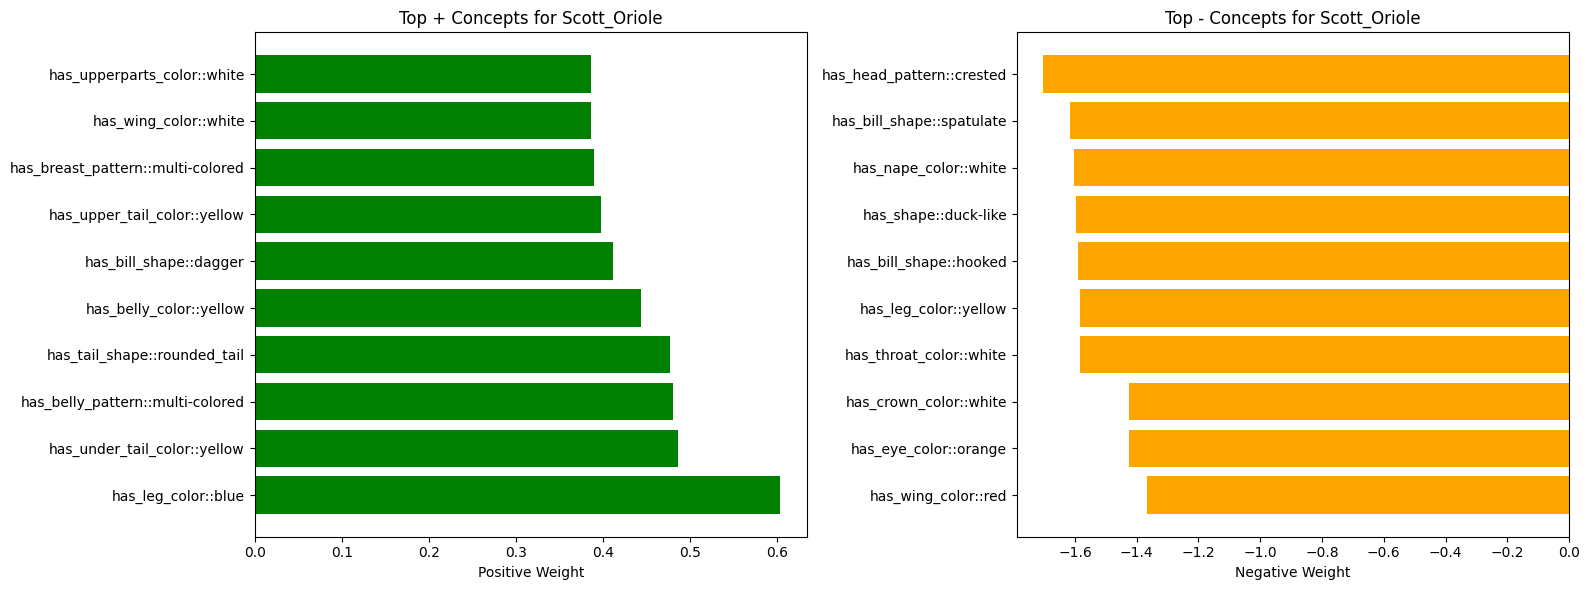

In [ ]:
import matplotlib.pyplot as plt
# Copies so originals stay intact
pos = df_top.copy()
neg = df_down.copy()
# Sort (weak : strong from top to bottom)
pos = pos.sort_values("weight", ascending=True)
neg = neg.sort_values("weight", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
# LEFT: Positive concepts (GREEN)
axes[0].barh(
    pos["concept_name"],
    pos["weight"],
    color="green"
)
axes[0].set_title(f"Top + Concepts for {id2label(pred_class)}")
axes[0].set_xlabel("Positive Weight")
axes[0].invert_yaxis()
# RIGHT: Negative concepts (ORANGE)
axes[1].barh(
    neg["concept_name"],
    neg["weight"],
    color="orange"   #
)
axes[1].set_title(f"Top - Concepts for {id2label(pred_class)}")
axes[1].set_xlabel("Negative Weight")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
concept_idx = int(df_top.iloc[0]["concept_idx"])
concept_name = df_top.iloc[0]["concept_name"]
print("Intervening on high-weight concept:", concept_idx, concept_name)
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x,
    {139: 0},   # removing a strong positive concept
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred, id2label(new_pred))
print(concept_name, "before:", float(c_before[concept_idx]), "after:", float(c_after[concept_idx]))

Intervening on high-weight concept: 263 has_leg_color::blue
Base: 97 Scott_Oriole
New : 97 Scott_Oriole
has_leg_color::blue before: 0.5608770847320557 after: 0.5608770847320557


In [ ]:
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x,
    {56: 1.0},
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred, id2label(new_pred))

Base: 97 Scott_Oriole
New : 97 Scott_Oriole


In [ ]:
# Trying multiple interventions (Koh et al. style):

In [ ]:
changes = {
    97: 0.0,    # head masked
    126: 0.1,   # throat yellow
    298: 0.0,   # crown grey
}
base_pred, new_pred, _, _ = intervene_on_image(
    model_for_intervention,
    x,
    changes,
    device=device
)
print("Base pred:", base_pred, id2label(base_pred))
print("New  pred:", new_pred, id2label(new_pred))

Base pred: 97 Scott_Oriole
New  pred: 97 Scott_Oriole


In [ ]:
def get_top_bottom_for_image(idx, model, top_k=10):
    # 1) load sample
    sample = ds["test"][idx]
    img = sample["image"]           # PIL
    true_cls = int(sample["label"])

    # 2) show the image (small)
    plt.figure(figsize=(5, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"idx={idx} | {id2label(true_cls)}")
    plt.show()

    # 3) preprocess and run model
    x = test_transform(img).to(device)  # [3,H,W]
    model.eval()
    with torch.no_grad():
        feats = model.backbone(x.unsqueeze(0))
        c_probs, c_logits = model.concepts(feats)
        logits = model.label(c_probs)
        pred_cls = int(logits.argmax(1).item())

    print(f"\nImage idx: {idx}")
    print("True class:", true_cls, id2label(true_cls))
    print("Pred class:", pred_cls, id2label(pred_cls))

    # 4) build concept table
    row = W[pred_cls]
    if isinstance(row, torch.Tensor):
        row = row.detach().cpu().numpy()

    df = pd.DataFrame({
        "concept_idx": range(len(CUB_ATTRIBUTE_NAMES)),
        "concept_name": CUB_ATTRIBUTE_NAMES,
        "pred_prob": c_probs[0].cpu().numpy(),
        "weight": row,
    })

    df_top  = df.sort_values("weight", ascending=False).head(top_k).reset_index(drop=True)
    df_down = df.sort_values("weight", ascending=True).head(top_k).reset_index(drop=True)

    print("\nTop + concepts:")
    display(df_top)

    print("\nTop - concepts:")
    display(df_down)

    # return x and df:
    return img, x, pred_cls, df_top, df_down

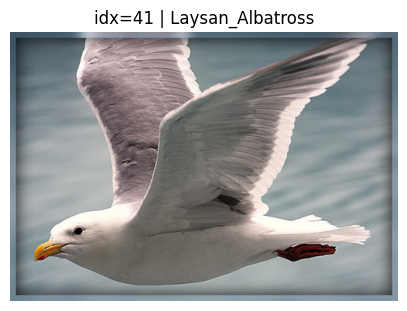


Image idx: 41
True class: 1 Laysan_Albatross
Pred class: 65 Western_Gull

Top + concepts:


,concept_idx,concept_name,pred_prob,weight
0,272,has_leg_color::pink,0.935750,0.493335
1,241,has_tail_pattern::spotted,0.165219,0.460473
2,222,has_shape::upright-perching_water-like,0.314754,0.451647
3,288,has_bill_color::orange,0.945255,0.446624
4,291,has_bill_color::red,0.329917,0.413513
5,33,has_upperparts_color::pink,0.185211,0.400280
6,141,has_eye_color::olive,0.598555,0.395281
7,301,has_crown_color::green,0.140793,0.352637
8,284,has_bill_color::yellow,0.968887,0.334091
9,70,has_back_color::white,0.984470,0.329594



Top - concepts:


,concept_idx,concept_name,pred_prob,weight
0,96,has_head_pattern::crested,0.002989,-1.437985
1,121,has_throat_color::brown,0.001858,-1.348876
2,3,has_bill_shape::needle,0.014090,-1.326912
3,167,has_under_tail_color::blue,0.000224,-1.308294
4,153,has_forehead_color::brown,0.000488,-1.164545
5,85,has_upper_tail_color::yellow,0.000033,-1.135281
6,224,has_shape::long-legged-like,0.129332,-1.066287
7,286,has_bill_color::green,0.012780,-1.062438
8,15,has_wing_color::yellow,0.031685,-1.048383
9,143,has_eye_color::pink,0.001622,-1.008448


In [ ]:
img_idx, x_idx, pred_cls_idx, df_top_idx, df_down_idx = get_top_bottom_for_image(
    idx=41,
    model=model_for_intervention,
    top_k=10
)

In [ ]:
concept_idx = int(df_top_idx.iloc[0]["concept_idx"])  # e.g. first top positive (or df_down ...)
concept_name = df_top_idx.iloc[0]["concept_name"]
print("Experimenting with concept:", concept_idx, concept_name)
values = np.linspace(0.0, 1.0, 10)  # 0.0, 0.1, ..., 1.0
for v in values:
    base_pred, new_pred, _, _ = intervene_on_image(
        model_for_intervention,
        x_idx,                      # image tensor returned from Cell A
        {concept_idx: float(v)},
        device=device
    )
    print(f"value={v:.1f} | base={id2label(base_pred)} | new={id2label(new_pred)}")

Experimenting with concept: 272 has_leg_color::pink
value=0.0 | base=Western_Gull | new=Western_Gull
value=0.1 | base=Western_Gull | new=Western_Gull
value=0.2 | base=Western_Gull | new=Western_Gull
value=0.3 | base=Western_Gull | new=Western_Gull
value=0.4 | base=Western_Gull | new=Western_Gull
value=0.6 | base=Western_Gull | new=Western_Gull
value=0.7 | base=Western_Gull | new=Western_Gull
value=0.8 | base=Western_Gull | new=Western_Gull
value=0.9 | base=Western_Gull | new=Western_Gull
value=1.0 | base=Western_Gull | new=Western_Gull


In [ ]:
concept_idx = int(df_top_idx.iloc[1]["concept_idx"])  # e.g. second top positive (or df_down ...)
concept_name = df_top_idx.iloc[1]["concept_name"]
print("Experimenting with concept:", concept_idx, concept_name)
values = np.linspace(0.0, 1.0, 10)  # 0.0, 0.1, ..., 1.0
for v in values:
    base_pred, new_pred, _, _ = intervene_on_image(
        model_for_intervention,
        x_idx,                      # image tensor returned from Cell A
        {concept_idx: float(v)},
        device=device
    )
    print(f"value={v:.1f} | base={id2label(base_pred)} | new={id2label(new_pred)}")

Experimenting with concept: 241 has_tail_pattern::spotted
value=0.0 | base=Western_Gull | new=Western_Gull
value=0.1 | base=Western_Gull | new=Western_Gull
value=0.2 | base=Western_Gull | new=Western_Gull
value=0.3 | base=Western_Gull | new=Western_Gull
value=0.4 | base=Western_Gull | new=Western_Gull
value=0.6 | base=Western_Gull | new=Western_Gull
value=0.7 | base=Western_Gull | new=Western_Gull
value=0.8 | base=Western_Gull | new=Western_Gull
value=0.9 | base=Western_Gull | new=Western_Gull
value=1.0 | base=Western_Gull | new=Western_Gull


In [ ]:
# intervene on 3 concepts at once:
changes = {
    96: 0.9,   # has_head_pattern::masked
    121: 0.8,  # has_throat_color::yellow
    3: 0.8,  # has_crown_color::grey
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_idx,          # image tensor [3,H,W]
    changes,        # <-- multiple concepts here
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 65 Western_Gull
New : 59 Glaucous_winged_Gull


In [ ]:
# intervene on 3 concepts at once:
changes = {
    241: 0.0,   # has_head_pattern::masked
    121: 0.7,  # has_throat_color::yellow
    96: 0.9,  # has_crown_color::grey
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_idx,          # image tensor [3,H,W]
    changes,        # <-- multiple concepts here
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 65 Western_Gull
New : 61 Herring_Gull


--- Finding misclassified test images + printing their names

--- Picking one wrong image, inspect its top concepts, and try correcting concepts toward the ground truth:

In [ ]:
# Find misclassified test images (index + names):
def get_misclassified_test_examples(model, max_examples=None):
    wrong = []
    model.eval()

    for idx in range(len(ds["test"])):
        sample = ds["test"][idx]
        img = sample["image"]
        y_true = int(sample["label"])

        x = test_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feats = model.backbone(x)
            c_probs, _ = model.concepts(feats)
            logits = model.label(c_probs)
            y_pred = int(logits.argmax(1).item())

        if y_pred != y_true:
            wrong.append({"idx": idx, "y_true": y_true, "y_pred": y_pred})

        if max_examples is not None and len(wrong) >= max_examples:
            break

    return wrong

In [ ]:
wrong_examples = get_misclassified_test_examples(model_for_intervention, max_examples=30)
for e in wrong_examples:
    print(
        f"idx={e['idx']:4d} | true={id2label(e['y_true'])} | pred={id2label(e['y_pred'])}"
    )

idx=   5 | true=Black_footed_Albatross | pred=Sooty_Albatross
idx=  12 | true=Black_footed_Albatross | pred=Pomarine_Jaeger
idx=  19 | true=Black_footed_Albatross | pred=Rhinoceros_Auklet
idx=  23 | true=Black_footed_Albatross | pred=Brandt_Cormorant
idx=  24 | true=Black_footed_Albatross | pred=Long_tailed_Jaeger
idx=  26 | true=Black_footed_Albatross | pred=Pomarine_Jaeger
idx=  28 | true=Black_footed_Albatross | pred=Laysan_Albatross
idx=  34 | true=Laysan_Albatross | pred=Caspian_Tern
idx=  38 | true=Laysan_Albatross | pred=Ivory_Gull
idx=  41 | true=Laysan_Albatross | pred=Western_Gull
idx=  42 | true=Laysan_Albatross | pred=Cactus_Wren
idx=  43 | true=Laysan_Albatross | pred=California_Gull
idx=  44 | true=Laysan_Albatross | pred=Black_footed_Albatross
idx=  48 | true=Laysan_Albatross | pred=Caspian_Tern
idx=  51 | true=Laysan_Albatross | pred=Caspian_Tern
idx=  55 | true=Laysan_Albatross | pred=Black_footed_Albatross
idx=  56 | true=Laysan_Albatross | pred=California_Gull
idx=  

In [ ]:
wrong_example = wrong_examples[0]
idx_wrong = wrong_example["idx"]
print("Using misclassified idx:", idx_wrong)

Using misclassified idx: 5


For one misclassified image: top concepts + concept corrections.

Getting top/ bottom concepts for this wrongly predicted image:

In [ ]:
#n_classes = 200
#n_concepts = 312

def class_concept_profile(split="train", top_k=15, min_freq=None):
    # collect labels + attributes
    y = np.array(ds[split]["label"])
    A = np.stack(ds[split]["attributes"]).astype(float)  # [N,312]

    rows = []
    for cls in sorted(np.unique(y)):
        mask = (y == cls)
        freq = A[mask].mean(axis=0)   # P(attr=1 | class)
        idxs = np.argsort(freq)[::-1] # high → low

        if min_freq is not None:
            idxs = [j for j in idxs if freq[j] >= min_freq][:top_k]
        else:
            idxs = idxs[:top_k]

        for rank, j in enumerate(idxs, 1):
            rows.append({
                "class_id": int(cls),
                "class_name": id2label(int(cls)),
                "rank": rank,
                "concept_idx": int(j),
                "concept_name": CUB_ATTRIBUTE_NAMES[int(j)],
                "freq_in_class": float(freq[int(j)]),
            })

    return pd.DataFrame(rows)

df_class_gt = class_concept_profile(split="train", top_k=10)
df_class_gt.head(200)

,class_id,class_name,rank,concept_idx,concept_name,freq_in_class
0,0,Black_footed_Albatross,1,149,has_bill_length::about_the_same_as_head,0.740741
1,0,Black_footed_Albatross,2,220,has_size::medium_(9_-_16_in),0.703704
2,0,Black_footed_Albatross,3,145,has_eye_color::black,0.666667
3,0,Black_footed_Albatross,4,4,has_bill_shape::hooked_seabird,0.555556
4,0,Black_footed_Albatross,5,244,has_belly_pattern::solid,0.518519
...,...,...,...,...,...,...
195,19,Yellow_breasted_Chat,6,203,has_belly_color::yellow,0.851852
196,19,Yellow_breasted_Chat,7,151,has_bill_length::shorter_than_head,0.814815
197,19,Yellow_breasted_Chat,8,254,has_primary_color::yellow,0.777778
198,19,Yellow_breasted_Chat,9,289,has_bill_color::black,0.703704


In [ ]:
import pandas as pd
# CUB_ATTRIBUTE_NAMES = [...]
df_concepts = pd.DataFrame({
    "concept_idx": range(len(CUB_ATTRIBUTE_NAMES)),
    "concept_name": CUB_ATTRIBUTE_NAMES,
})

df_concepts.head(313)

,concept_idx,concept_name
0,0,has_bill_shape::curved_(up_or_down)
1,1,has_bill_shape::dagger
2,2,has_bill_shape::hooked
3,3,has_bill_shape::needle
4,4,has_bill_shape::hooked_seabird
...,...,...
307,307,has_crown_color::buff
308,308,has_wing_pattern::solid
309,309,has_wing_pattern::spotted
310,310,has_wing_pattern::striped


In [ ]:
def get_top_bottom_for_wrong_image(idx, model, top_k=10):
    sample = ds["test"][idx]
    img = sample["image"]
    y_true = int(sample["label"])
    # show image
    plt.figure(figsize=(5, 9))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"idx={idx} | true={id2label(y_true)}")
    plt.show()

    # forward pass
    x = test_transform(img).to(device)  # [3,H,W]
    model.eval()
    with torch.no_grad():
        feats = model.backbone(x.unsqueeze(0))
        c_probs, _ = model.concepts(feats)
        logits = model.label(c_probs)
        pred_cls = int(logits.argmax(1).item())

    print("True class:", y_true, id2label(y_true))
    print("Pred class:", pred_cls, id2label(pred_cls))

    # build concept table for the *predicted* class
    row = W[pred_cls]
    if isinstance(row, torch.Tensor):
        row = row.detach().cpu().numpy()

    df = pd.DataFrame({
        "concept_idx": range(len(CUB_ATTRIBUTE_NAMES)),
        "concept_name": CUB_ATTRIBUTE_NAMES,
        "pred_prob": c_probs[0].cpu().numpy(),
        "weight": row,
    })

    df_top  = df.sort_values("weight", ascending=False).head(top_k).reset_index(drop=True)
    df_down = df.sort_values("weight", ascending=True).head(top_k).reset_index(drop=True)

    print("\nTop + concepts (for predicted class):")
    display(df_top)

    print("\nTop - concepts (for predicted class):")
    display(df_down)

    return img, x, y_true, pred_cls, c_probs[0].cpu(), df_top, df_down

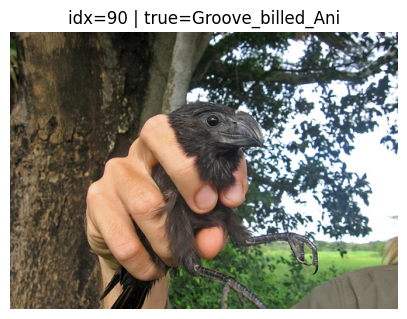

True class: 3 Groove_billed_Ani
Pred class: 113 Black_throated_Sparrow

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,131,has_throat_color::black,0.903866,0.746861
1,116,has_breast_color::black,0.735691,0.647522
2,99,has_head_pattern::eyebrow,0.199378,0.600809
3,236,has_back_pattern::solid,0.400658,0.454929
4,7,has_bill_shape::cone,0.854429,0.440628
5,290,has_bill_color::white,0.236365,0.430247
6,95,has_head_pattern::malar,0.452168,0.420628
7,264,has_leg_color::brown,0.898805,0.414402
8,143,has_eye_color::pink,0.191252,0.387430
9,50,has_underparts_color::black,0.581582,0.382969



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,94,has_head_pattern::spotted,0.046159,-2.057399
1,103,has_head_pattern::striped,0.011691,-1.995561
2,188,has_nape_color::yellow,0.010366,-1.861374
3,147,has_eye_color::red,0.004771,-1.840078
4,101,has_head_pattern::plain,0.472520,-1.765914
5,284,has_bill_color::yellow,0.034820,-1.708531
6,1,has_bill_shape::dagger,0.039753,-1.674640
7,73,has_tail_shape::forked_tail,0.077083,-1.666385
8,203,has_belly_color::yellow,0.224226,-1.581468
9,267,has_leg_color::rufous,0.006558,-1.559249


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    90,
    model_for_intervention,
    top_k=10
)

In [ ]:
# choosing concept indices from df_top_w / df_down_w:
changes = {
    131: 0.2,   # I chandged it from 0.9 to 0.2, so base and new are not the same...(high weight concept)
    103: 0.9,   # (low weight concept) (0.9 instead of 0.1 for example...)
    116: 0.1,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 113 Black_throated_Sparrow
New : 38 Least_Flycatcher


In [ ]:
changes = {
    131: 0.8,
    103: 0.2,
    116: 0.9,
}

base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 113 Black_throated_Sparrow
New : 113 Black_throated_Sparrow


In [ ]:
# choosing concept indices from df_top_w / df_down_w:
changes = {
    131: 0.8,   # If i put 0.09, base and new is same, but I chandged it from 0.9 to 0.2, so base and new are not the same...(high weight concept)
    103: 0.7,   # (low weight concept) (0.9 instead of 0.1 for example...)
    116: 0.9,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 113 Black_throated_Sparrow
New : 113 Black_throated_Sparrow


In [ ]:
# choosing concept indices from df_top_w / df_down_w:
changes = {
    94: 0.8,
    103: 0.9,
    116: 0.1,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 113 Black_throated_Sparrow
New : 124 Lincoln_Sparrow


In [ ]:
# choosing concept indices from df_top_w / df_down_w:
changes = {
    103: 0.8,
    94: 0.7,
    1: 1.0,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 113 Black_throated_Sparrow
New : 124 Lincoln_Sparrow


In [ ]:
# choosing concept indices from df_top_w / df_down_w:
changes = {
    308: 0.8,
    290: 0.7,
    1: 0.9,
}

base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 113 Black_throated_Sparrow
New : 113 Black_throated_Sparrow


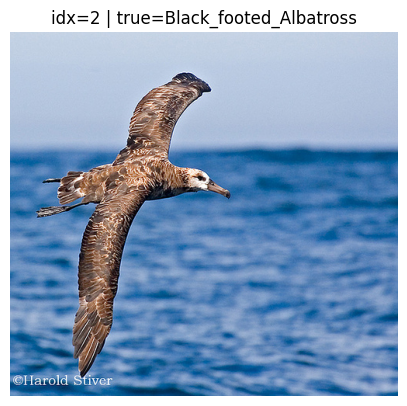

True class: 0 Black_footed_Albatross
Pred class: 0 Black_footed_Albatross

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,4,has_bill_shape::hooked_seabird,0.999497,0.824814
1,305,has_crown_color::white,0.995230,0.656462
2,164,has_forehead_color::white,0.982312,0.593223
3,216,has_wing_shape::long-wings,0.948051,0.542543
4,220,has_size::medium_(9_-_16_in),0.817386,0.529708
5,227,has_shape::gull-like,0.849464,0.519051
6,5,has_bill_shape::spatulate,0.101281,0.473505
7,102,has_head_pattern::eyeline,0.350178,0.472551
8,225,has_shape::duck-like,0.092817,0.471949
9,95,has_head_pattern::malar,0.472882,0.431441



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,273,has_leg_color::orange,0.002495,-2.017496
1,144,has_eye_color::orange,0.002946,-1.900063
2,254,has_primary_color::yellow,0.001087,-1.702033
3,188,has_nape_color::yellow,0.000326,-1.653179
4,192,has_nape_color::orange,0.001480,-1.538033
5,111,has_breast_color::yellow,0.000048,-1.492433
6,48,has_underparts_color::pink,0.000410,-1.449553
7,85,has_upper_tail_color::yellow,0.000329,-1.448275
8,135,has_eye_color::blue,0.024340,-1.418693
9,96,has_head_pattern::crested,0.005114,-1.410758


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    2,
    model_for_intervention,
    top_k=10
)

In [ ]:
changes = {
    273: 0.9,   # If i put 0.09, base and new is same, but I chandged it from 0.9 to 0.2, so base and new are not the same...(high weight concept)
    254: 0.9,   # (low weight concept) (0.9 instead of 0.1 for example...)
    4: 0.1,
    144: 0.9,
}

base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 0 Black_footed_Albatross
New : 0 Black_footed_Albatross


In [ ]:
changes = {
    254: 0.9,
    144: 0.9,
    273: 0.9,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 0 Black_footed_Albatross
New : 0 Black_footed_Albatross


In [ ]:
changes = {
    216: 0.1,
    306: 0.1,
    160: 0.1,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 0 Black_footed_Albatross
New : 0 Black_footed_Albatross


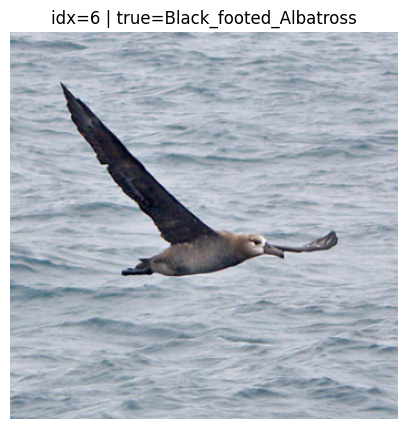

True class: 0 Black_footed_Albatross
Pred class: 0 Black_footed_Albatross

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,4,has_bill_shape::hooked_seabird,0.999205,0.824814
1,305,has_crown_color::white,0.966783,0.656462
2,164,has_forehead_color::white,0.935526,0.593223
3,216,has_wing_shape::long-wings,0.986063,0.542543
4,220,has_size::medium_(9_-_16_in),0.995732,0.529708
5,227,has_shape::gull-like,0.998147,0.519051
6,5,has_bill_shape::spatulate,0.918424,0.473505
7,102,has_head_pattern::eyeline,0.285424,0.472551
8,225,has_shape::duck-like,0.877368,0.471949
9,95,has_head_pattern::malar,0.076322,0.431441



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,273,has_leg_color::orange,0.046520,-2.017496
1,144,has_eye_color::orange,0.156275,-1.900063
2,254,has_primary_color::yellow,0.000388,-1.702033
3,188,has_nape_color::yellow,0.000690,-1.653179
4,192,has_nape_color::orange,0.000067,-1.538033
5,111,has_breast_color::yellow,0.000123,-1.492433
6,48,has_underparts_color::pink,0.002143,-1.449553
7,85,has_upper_tail_color::yellow,0.000053,-1.448275
8,135,has_eye_color::blue,0.002659,-1.418693
9,96,has_head_pattern::crested,0.002555,-1.410758


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    6,
    model_for_intervention,
    top_k=10
)

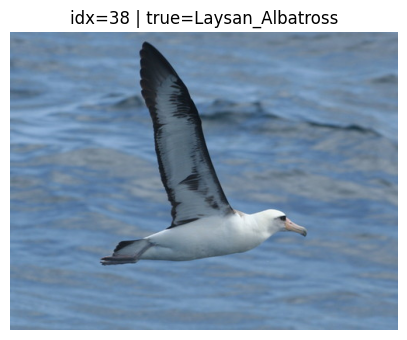

True class: 1 Laysan_Albatross
Pred class: 62 Ivory_Gull

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,274,has_leg_color::black,0.880111,0.873593
1,91,has_upper_tail_color::white,0.921709,0.436191
2,215,has_wing_shape::tapered-wings,0.835675,0.426554
3,179,has_under_tail_color::white,0.909979,0.405780
4,283,has_bill_color::grey,0.320598,0.394748
5,309,has_wing_pattern::spotted,0.048175,0.392453
6,70,has_back_color::white,0.802628,0.365851
7,36,has_upperparts_color::white,0.889966,0.359897
8,101,has_head_pattern::plain,0.956699,0.337119
9,236,has_back_pattern::solid,0.837838,0.336728



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,272,has_leg_color::pink,0.008440,-1.572842
1,306,has_crown_color::red,0.000184,-1.542916
2,230,has_shape::tree-clinging-like,0.000901,-1.448413
3,282,has_bill_color::rufous,0.008347,-1.394808
4,96,has_head_pattern::crested,0.001107,-1.354421
5,98,has_head_pattern::unique_pattern,0.002883,-1.292576
6,249,has_primary_color::brown,0.009151,-1.234974
7,254,has_primary_color::yellow,0.005502,-1.188486
8,280,has_bill_color::iridescent,0.000486,-1.134140
9,45,has_underparts_color::yellow,0.000272,-1.090575


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    38,
    model_for_intervention,
    top_k=10
)

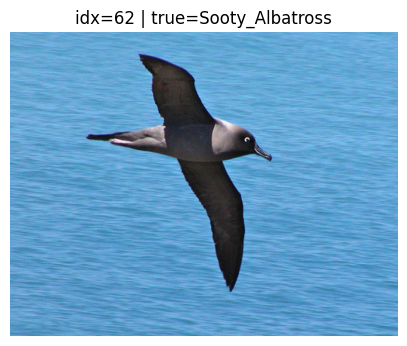

True class: 2 Sooty_Albatross
Pred class: 2 Sooty_Albatross

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,146,has_eye_color::white,0.993311,0.881217
1,4,has_bill_shape::hooked_seabird,0.999390,0.728849
2,227,has_shape::gull-like,0.990279,0.642816
3,98,has_head_pattern::unique_pattern,0.936937,0.552940
4,234,has_shape::swallow-like,0.154946,0.529492
5,216,has_wing_shape::long-wings,0.989296,0.475755
6,280,has_bill_color::iridescent,0.104275,0.460397
7,100,has_head_pattern::eyering,0.493054,0.430555
8,290,has_bill_color::white,0.784717,0.429324
9,149,has_bill_length::about_the_same_as_head,0.970673,0.421659



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,136,has_eye_color::brown,0.000944,-2.495829
1,138,has_eye_color::rufous,0.001298,-1.833721
2,147,has_eye_color::red,0.000721,-1.608051
3,282,has_bill_color::rufous,0.005797,-1.582033
4,273,has_leg_color::orange,0.002736,-1.539102
5,158,has_forehead_color::yellow,0.003948,-1.501075
6,269,has_leg_color::yellow,0.002792,-1.464184
7,228,has_shape::hummingbird-like,0.000509,-1.447008
8,142,has_eye_color::green,0.029775,-1.381770
9,165,has_forehead_color::red,0.295415,-1.375048


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    62,
    model_for_intervention,
    top_k=10
)

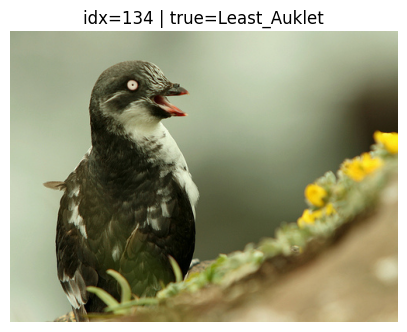

True class: 5 Least_Auklet
Pred class: 5 Least_Auklet

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,146,has_eye_color::white,0.985207,0.866644
1,246,has_belly_pattern::striped,0.651987,0.616412
2,266,has_leg_color::purple,0.222337,0.600963
3,275,has_leg_color::white,0.010734,0.593774
4,282,has_bill_color::rufous,0.697548,0.549618
5,222,has_shape::upright-perching_water-like,0.129309,0.517809
6,287,has_bill_color::pink,0.490501,0.517105
7,100,has_head_pattern::eyering,0.722968,0.490645
8,7,has_bill_shape::cone,0.897902,0.462097
9,233,has_shape::upland-ground-like,0.167226,0.460973



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,1,has_bill_shape::dagger,0.040483,-1.694863
1,226,has_shape::owl-like,0.031022,-1.664908
2,254,has_primary_color::yellow,0.014427,-1.616709
3,98,has_head_pattern::unique_pattern,0.033784,-1.535300
4,273,has_leg_color::orange,0.342082,-1.519874
5,276,has_leg_color::red,0.338459,-1.507951
6,188,has_nape_color::yellow,0.024247,-1.319284
7,126,has_throat_color::yellow,0.003620,-1.314331
8,269,has_leg_color::yellow,0.003292,-1.289968
9,224,has_shape::long-legged-like,0.006754,-1.269527


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    134,
    model_for_intervention,
    top_k=10
)

In [ ]:
changes = {
    226: 0.9,
    146: 0.0,
    1: 0.9,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 5 Least_Auklet
New : 6 Parakeet_Auklet


I decrease the weight of positive concepts because they resulted in wrong prediction, I found based on image, the resonable concepts and increase their weight
i increase negative weights for wrong predictions.

In [ ]:
changes = {
    288: 0.0,
    246: 0.1,
    146: 0.0,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 5 Least_Auklet
New : 6 Parakeet_Auklet


In [ ]:
changes = {
    132: 0.9,
    146: 0.8,
    51: 1.0,
    151: 0.8,
    117:0.7
}

base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)

print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 5 Least_Auklet
New : 6 Parakeet_Auklet


In [ ]:
changes = {
    0: 0.7,
    4: 0.7,
    17: 0.9,
    2 : 0.7,
    140 : 0.7,
    21:0.9,
    132: 0.6,
    146: 0.8,
    288: 0.0,
    136: 0.0,
    282: 0.0,
    273: 0.0,
}
base_pred, new_pred, c_before, c_after = intervene_on_image(
    model_for_intervention,
    x_w,          # x_w from previous Cell
    changes,
    device=device
)
print("Base:", base_pred, id2label(base_pred))
print("New :", new_pred,  id2label(new_pred))

Base: 5 Least_Auklet
New : 5 Least_Auklet


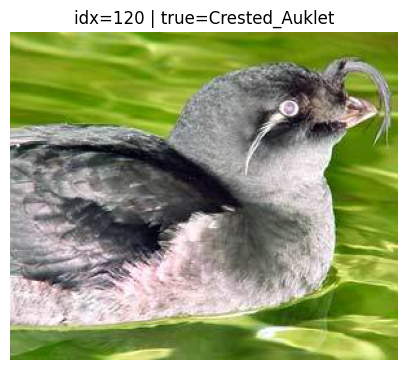

True class: 4 Crested_Auklet
Pred class: 7 Rhinoceros_Auklet

Top + concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,284,has_bill_color::yellow,0.505144,0.780168
1,225,has_shape::duck-like,0.996857,0.734903
2,288,has_bill_color::orange,0.178339,0.717602
3,95,has_head_pattern::malar,0.926144,0.673102
4,99,has_head_pattern::eyebrow,0.333238,0.520106
5,144,has_eye_color::orange,0.071891,0.485383
6,78,has_tail_shape::squared_tail,0.164832,0.432524
7,8,has_bill_shape::specialized,0.588159,0.396900
8,12,has_wing_color::purple,0.002721,0.395161
9,2,has_bill_shape::hooked,0.371478,0.381802



Top - concepts (for predicted class):


,concept_idx,concept_name,pred_prob,weight
0,230,has_shape::tree-clinging-like,0.012049,-1.851206
1,192,has_nape_color::orange,0.000036,-1.620696
2,73,has_tail_shape::forked_tail,0.001490,-1.529269
3,224,has_shape::long-legged-like,0.000017,-1.485868
4,226,has_shape::owl-like,0.008290,-1.468054
5,171,has_under_tail_color::rufous,0.000558,-1.430864
6,309,has_wing_pattern::spotted,0.003161,-1.407574
7,228,has_shape::hummingbird-like,0.005618,-1.406595
8,124,has_throat_color::rufous,0.000027,-1.386156
9,256,has_primary_color::green,0.005786,-1.366393


In [ ]:
img_w, x_w, y_true_w, y_pred_w, c_probs_w, df_top_w, df_down_w = get_top_bottom_for_wrong_image(
    120,
    model_for_intervention,
    top_k=10
)